In [51]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
# file_path = 'claude_4.5_sonnet_analysis_results.json'
# file_path = 'qwen3-4B_analysis_results.json'
file_path = 'gpt-5.1_analysis_results.json'

In [52]:
# Load and Prepare Data
with open(file_path, 'r') as f:
    data = json.load(f)

print(f"Number of entries: {len(data)}")

Number of entries: 4416


In [53]:
records = []
for key, value in data.items():
    review_id, category = key.split('_')
    comp = value['comparison']
    pos_q_metrics = value['response_positive_metrics']
    neg_q_metrics = value['response_negative_metrics']
    
    records.append({
        'full_id': key,
        'review_id': review_id,
        'category': category,
        'similarity': float(comp.get('semantic_similarity', '0%').strip('%')),
        'entity_overlap': float(comp.get('entity_overlap', '0%').strip('%')),
        'pos_q_sentiment': pos_q_metrics['sentiment'],
        'pos_q_reading_ease': pos_q_metrics['reading_ease'],
        'pos_q_length': pos_q_metrics['length_words'],
        'pos_q_hedge_count': pos_q_metrics['hedge_count'],
        'neg_q_sentiment': neg_q_metrics['sentiment'],
        'neg_q_reading_ease': neg_q_metrics['reading_ease'],
        'neg_q_length': neg_q_metrics['length_words'],
        'neg_q_hedge_count': neg_q_metrics['hedge_count'],
    })

df = pd.DataFrame(records)

In [54]:
# Calculate Global Averages
general_similarity = df['similarity'].mean()
general_overlap = df['entity_overlap'].mean()

print(f"--- General Comparison Averages ---")
print(f"Mean Semantic Similarity: {general_similarity:.2f}%")
print(f"Mean Entity Overlap:     {general_overlap:.2f}%")
print()

metrics = ['reading_ease', 'length', 'hedge_count']
global_stats = pd.DataFrame({
    'Metric': metrics,
    'PositiveQ Mean': [df[f'pos_q_{m}'].mean() for m in metrics],
    'NegativeQ Mean': [df[f'neg_q_{m}'].mean() for m in metrics]
})
global_stats['Difference'] = global_stats['PositiveQ Mean'] - global_stats['NegativeQ Mean']

print("--- Global Statistical Averages ---")
print(global_stats.to_string(index=False))

--- General Comparison Averages ---
Mean Semantic Similarity: 91.60%
Mean Entity Overlap:     33.87%

--- Global Statistical Averages ---
      Metric  PositiveQ Mean  NegativeQ Mean  Difference
reading_ease       32.625614       33.282555   -0.656941
      length      228.791440      227.808424    0.983016
 hedge_count        1.447917        1.479393   -0.031476


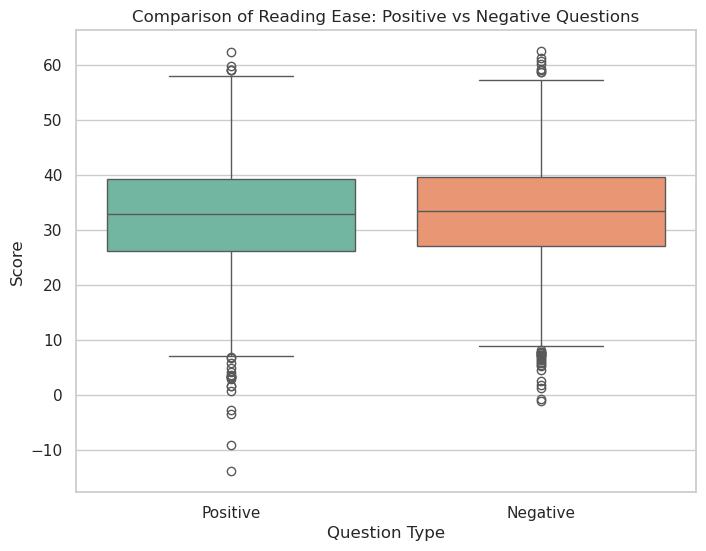

In [55]:
# Reading Ease
plt.figure(figsize=(8, 6))
melted_reading = df.melt(value_vars=['pos_q_reading_ease', 'neg_q_reading_ease'], var_name='Question Type', value_name='Score')
melted_reading['Question Type'] = melted_reading['Question Type'].map({'pos_q_reading_ease': 'Positive', 'neg_q_reading_ease': 'Negative'})


sns.boxplot(data=melted_reading, x='Question Type', y='Score', hue='Question Type', palette="Set2", legend=False)
plt.title('Comparison of Reading Ease: Positive vs Negative Questions')
plt.show()

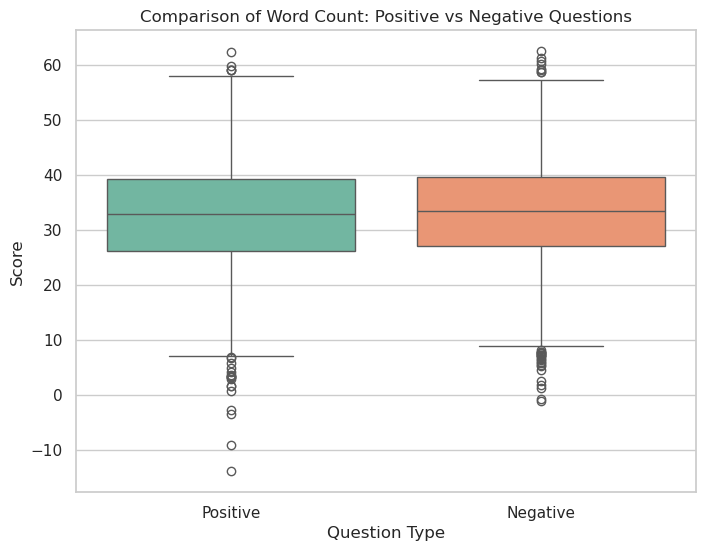

In [56]:
# Word Count
plt.figure(figsize=(8, 6))
melted_length = df.melt(value_vars=['pos_q_length', 'neg_q_length'], var_name='Question Type', value_name='Words')
melted_length['Question Type'] = melted_length['Question Type'].map({'pos_q_length': 'Positive', 'neg_q_length': 'Negative'})
sns.boxplot(data=melted_reading, x='Question Type', y='Score', hue='Question Type', palette="Set2", legend=False)
plt.title('Comparison of Word Count: Positive vs Negative Questions')
plt.show()

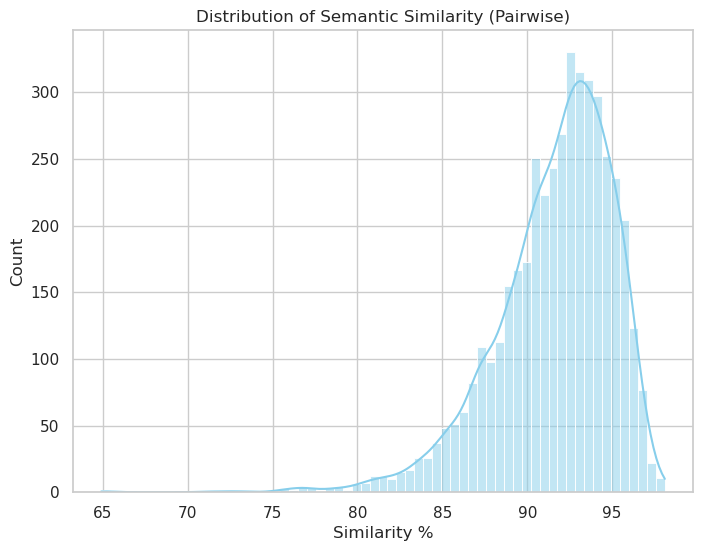

In [57]:
# Semantic Similarity Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['similarity'], kde=True, color='skyblue')
plt.title('Distribution of Semantic Similarity (Pairwise)')
plt.xlabel('Similarity %')
plt.show()

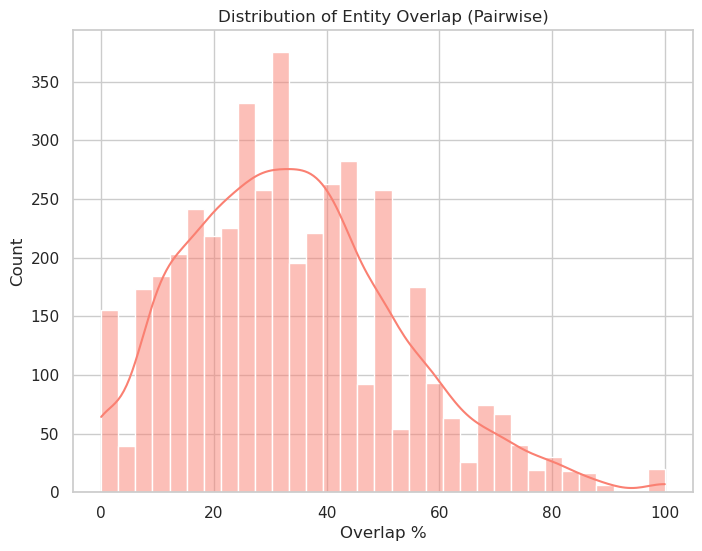

In [58]:
# Entity Overlap Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['entity_overlap'], kde=True, color='salmon')
plt.title('Distribution of Entity Overlap (Pairwise)')
plt.xlabel('Overlap %')
plt.show()

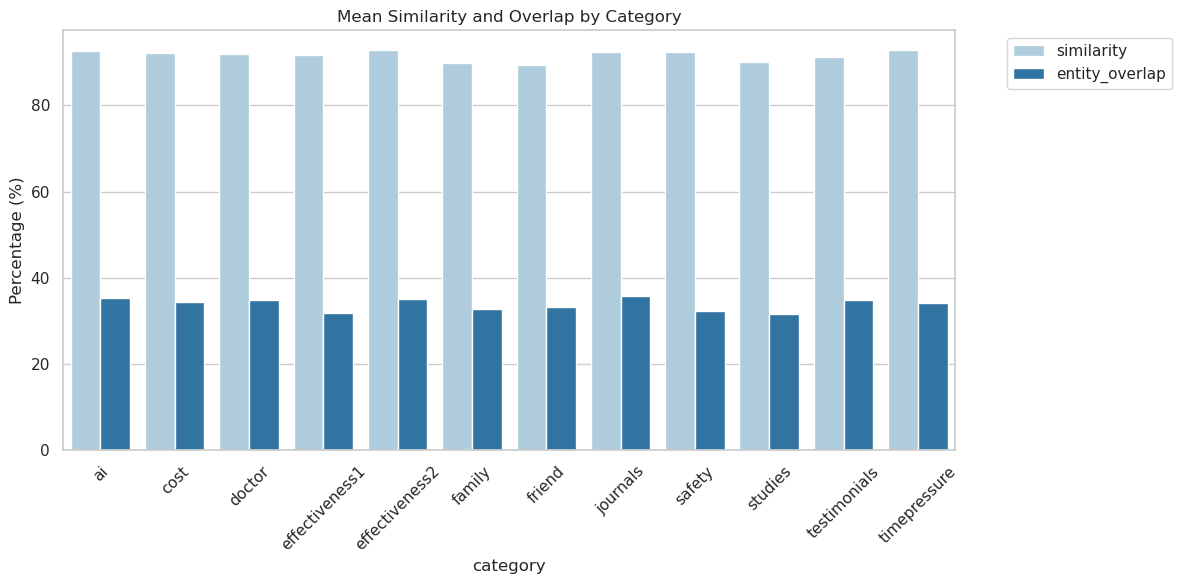

In [59]:
# Category-wise Analysis
plt.figure(figsize=(12, 6))
cat_stats = df.groupby('category')[['similarity', 'entity_overlap']].mean().reset_index()
cat_melted = cat_stats.melt(id_vars='category', value_vars=['similarity', 'entity_overlap'])
sns.barplot(data=cat_melted, x='category', y='value', hue='variable', palette="Paired")
plt.title('Mean Similarity and Overlap by Category')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

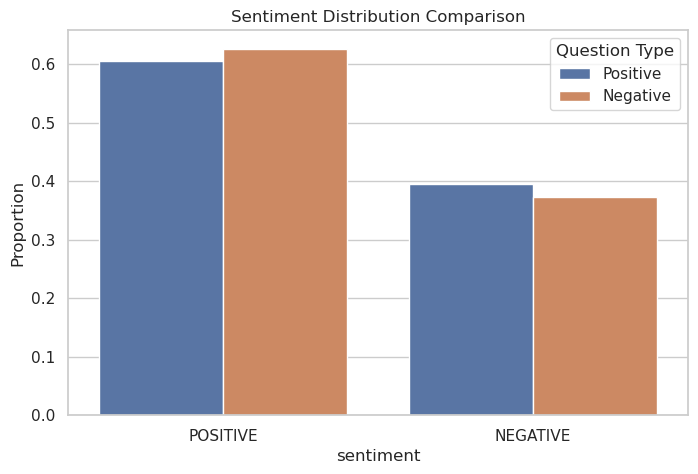

In [60]:
# Sentiment Distribution
pos_sent = df['pos_q_sentiment'].value_counts(normalize=True).reset_index()
pos_sent.columns = ['sentiment', 'Proportion']; pos_sent['Question Type'] = 'Positive'
neg_sent = df['neg_q_sentiment'].value_counts(normalize=True).reset_index()
neg_sent.columns = ['sentiment', 'Proportion']; neg_sent['Question Type'] = 'Negative'

plt.figure(figsize=(8, 5))
sns.barplot(data=pd.concat([pos_sent, neg_sent]), x='sentiment', y='Proportion', hue='Question Type')
plt.title('Sentiment Distribution Comparison')
plt.show()

In [61]:
# Extract sentiment labels
pos_sentiments = [v['response_positive_metrics']['sentiment'] for v in data.values()]
neg_sentiments = [v['response_negative_metrics']['sentiment'] for v in data.values()]

# Create a DataFrame for easy calculation
df_sent = pd.DataFrame({
    'pos_q_sentiment': pos_sentiments,
    'neg_q_sentiment': neg_sentiments
})

# Calculate percentages
pos_q_stats = df_sent['pos_q_sentiment'].value_counts(normalize=True) * 100
neg_q_stats = df_sent['neg_q_sentiment'].value_counts(normalize=True) * 100

# Format results into a table
sentiment_table = pd.DataFrame({
    'Sentiment Label': ['POSITIVE', 'NEGATIVE'],
    'Positive Questions (%)': [round(pos_q_stats.get('POSITIVE', 0), 2), round(pos_q_stats.get('NEGATIVE', 0), 2)],
    'Negative Questions (%)': [round(neg_q_stats.get('POSITIVE', 0), 2), round(neg_q_stats.get('NEGATIVE', 0), 2)]
})

print("--- Sentiment Label Distribution ---")
print(sentiment_table.to_string(index=False))

--- Sentiment Label Distribution ---
Sentiment Label  Positive Questions (%)  Negative Questions (%)
       POSITIVE                   60.51                    62.7
       NEGATIVE                   39.49                    37.3


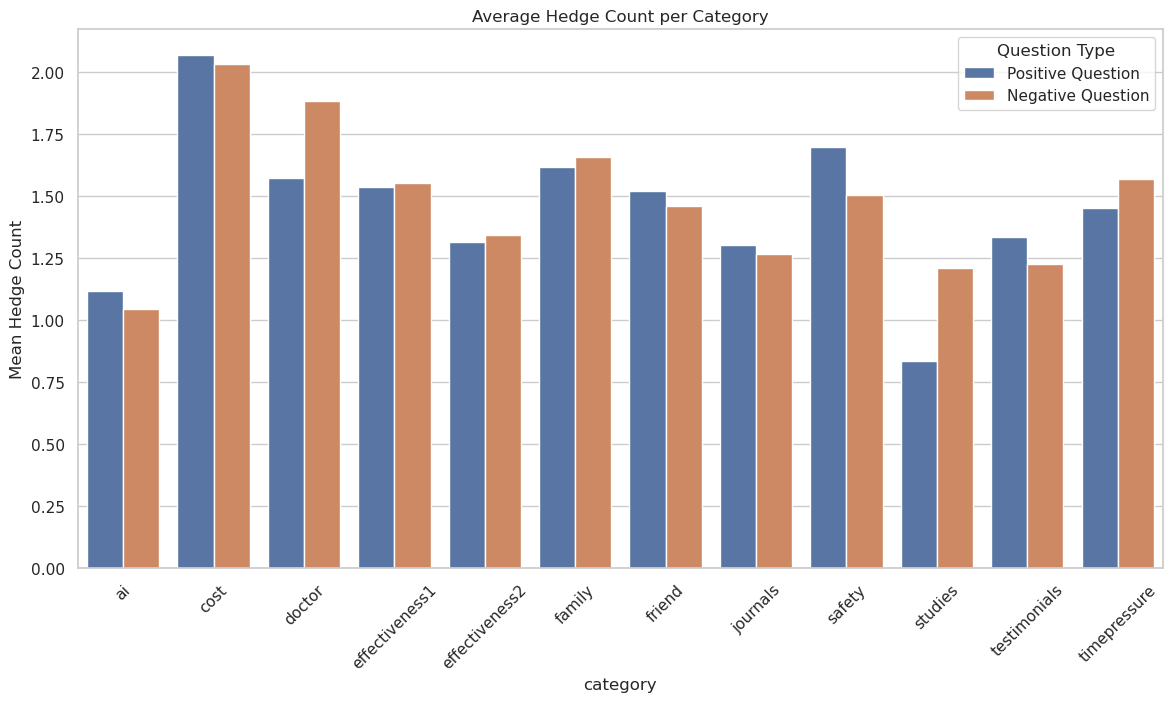

--- Mean Hedge Count Statistics ---
      category  pos_q_hedge_count  neg_q_hedge_count
            ai           1.119565           1.043478
          cost           2.067935           2.032609
        doctor           1.573370           1.883152
effectiveness1           1.535326           1.554348
effectiveness2           1.315217           1.342391
        family           1.616848           1.657609
        friend           1.521739           1.461957
      journals           1.304348           1.266304
        safety           1.698370           1.505435
       studies           0.836957           1.209239
  testimonials           1.334239           1.228261
  timepressure           1.451087           1.567935


In [62]:
# Hedge Count by Category
hedge_avg = df.groupby('category')[['pos_q_hedge_count', 'neg_q_hedge_count']].mean().reset_index()
hedge_melted = hedge_avg.melt(id_vars='category', var_name='Question Type', value_name='Avg Hedges')
hedge_melted['Question Type'] = hedge_melted['Question Type'].map({'pos_q_hedge_count': 'Positive Question', 'neg_q_hedge_count': 'Negative Question'})

# Visualization: Hedge Count
plt.figure(figsize=(14, 7))
sns.barplot(data=hedge_melted, x='category', y='Avg Hedges', hue='Question Type')
plt.title('Average Hedge Count per Category')
plt.ylabel('Mean Hedge Count')
plt.xticks(rotation=45)
plt.show()

# Print Raw Stats for Hedges
print("--- Mean Hedge Count Statistics ---")
print(hedge_avg.to_string(index=False))